# ECG Arrhythmia Dataset – EDA & Visualization  
### MIT-BIH Arrhythmia Database  
- Dataset structure & file types  
- Sampling rates, signal metadata  
- Signal plots at different scales  
- Annotation (beat types, symbols, categories)  
- Beat distribution across all 48 records  
- Inter-record variability  
- Noise characteristics & examples  
- R-peak analysis  


In [56]:
import os
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [58]:
DATA_PATH = "../Data/Raw"   # Change if needed
records = sorted(list(set([f.split('.')[0] for f in os.listdir(DATA_PATH) if f.endswith('.dat')])))
len(records), records[:10]


(48, ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109'])

In [60]:
record_id = "100"
record = wfdb.rdrecord(os.path.join(DATA_PATH, record_id))
annotation = wfdb.rdann(os.path.join(DATA_PATH, record_id), "atr")

record.__dict__.keys()


dict_keys(['record_name', 'n_sig', 'fs', 'counter_freq', 'base_counter', 'sig_len', 'base_time', 'base_date', 'comments', 'sig_name', 'p_signal', 'd_signal', 'e_p_signal', 'e_d_signal', 'file_name', 'fmt', 'samps_per_frame', 'skew', 'byte_offset', 'adc_gain', 'baseline', 'units', 'adc_res', 'adc_zero', 'init_value', 'checksum', 'block_size'])

## Record Metadata
Understanding signal properties before analysis is essential.


In [63]:
print("Sampling frequency:", record.fs)
print("Signal names:", record.sig_name)
print("Number of channels:", record.n_sig)
print("Baseline:", record.baseline)
print("ADC gain:", record.adc_gain)
print("Units:", record.units)
print("Signal length:", len(record.p_signal))


Sampling frequency: 360
Signal names: ['MLII', 'V5']
Number of channels: 2
Baseline: [1024, 1024]
ADC gain: [200.0, 200.0]
Units: ['mV', 'mV']
Signal length: 650000


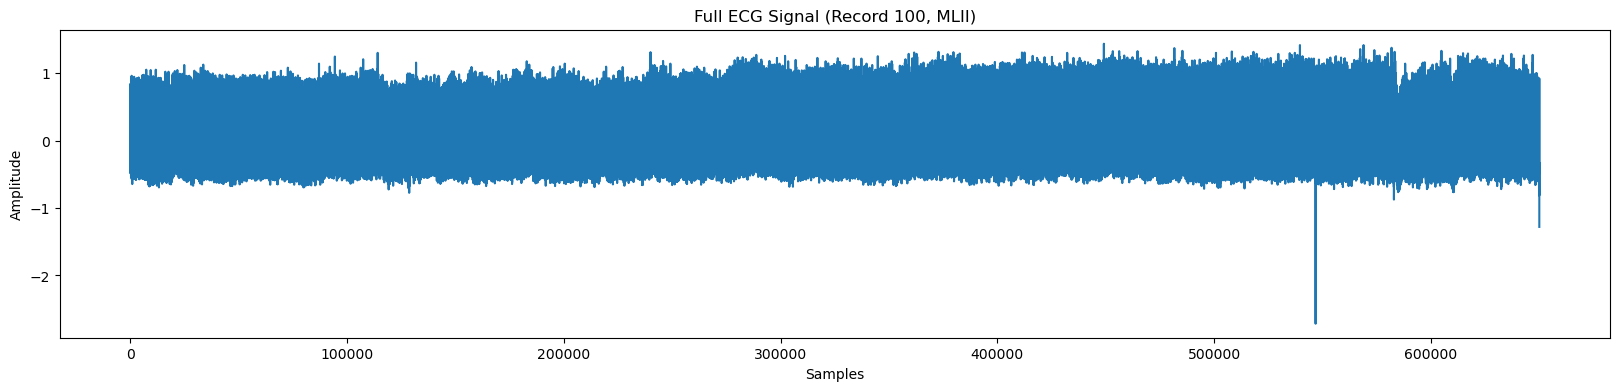

In [65]:
plt.figure(figsize=(20,4))
plt.plot(record.p_signal[:,0])
plt.title("Full ECG Signal (Record 100, MLII)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


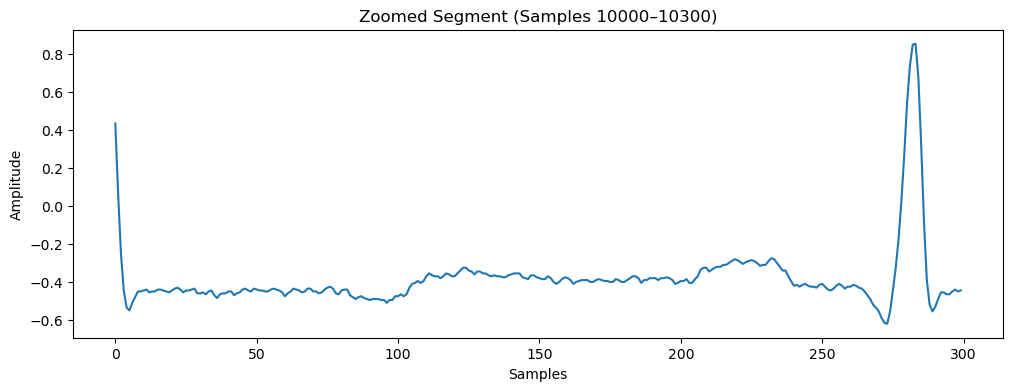

In [66]:
start, end = 10000, 10300
plt.figure(figsize=(12,4))
plt.plot(record.p_signal[start:end,0])
plt.title("Zoomed Segment (Samples 10000–10300)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


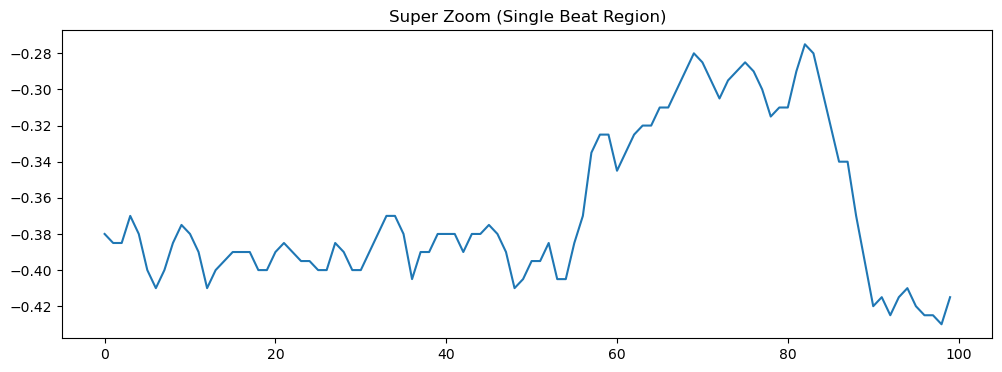

In [67]:
start, end = 10150, 10250
plt.figure(figsize=(12,4))
plt.plot(record.p_signal[start:end,0])
plt.title("Super Zoom (Single Beat Region)")
plt.show()


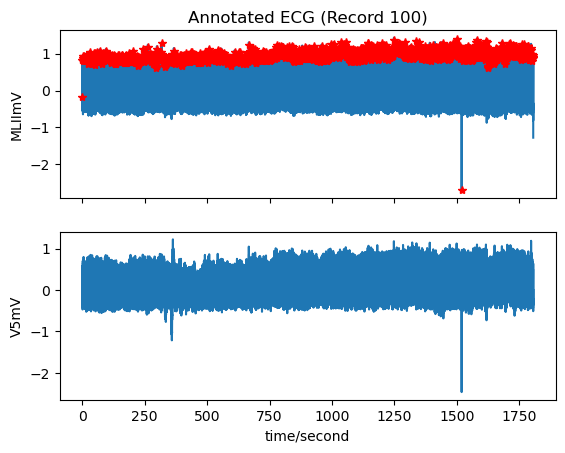

In [68]:
wfdb.plot_wfdb(record=record, annotation=annotation, title="Annotated ECG (Record 100)")


Signal shape: (650000, 2)
Leads: ['MLII', 'V5']
Sampling freq: 360


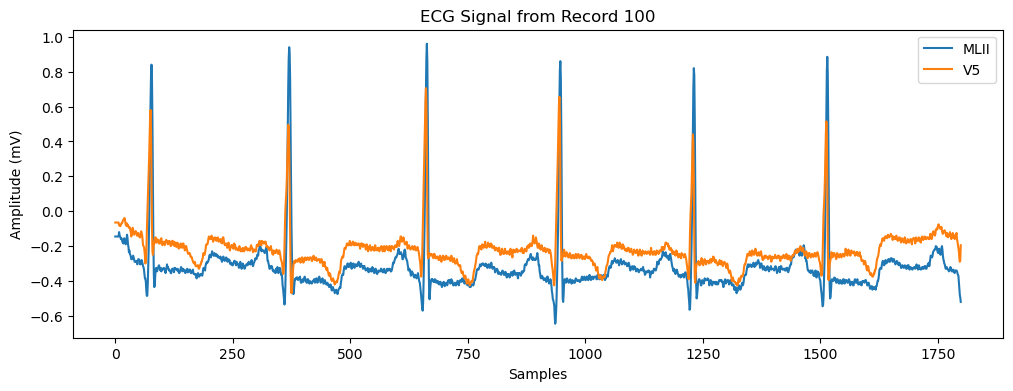

In [70]:
print("Signal shape:", record.p_signal.shape)
print("Leads:", record.sig_name)
print("Sampling freq:", record.fs)

# Plot first 5 seconds
fs = record.fs
plt.figure(figsize=(12,4))
plt.plot(record.p_signal[:5*fs,0], label='MLII')
plt.plot(record.p_signal[:5*fs,1], label='V5')
plt.title('ECG Signal from Record 100')
plt.xlabel('Samples')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()


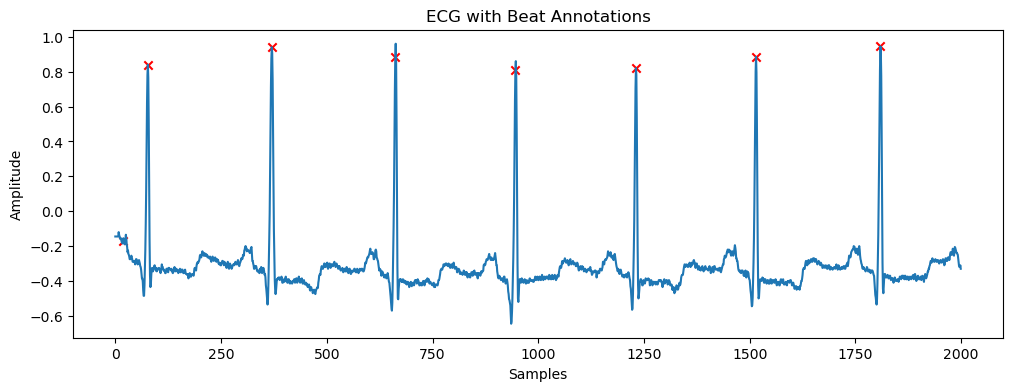

In [72]:
plt.figure(figsize=(12,4))
plt.plot(record.p_signal[:2000,0], label='ECG')
for idx, sym in zip(annotation.sample, annotation.symbol):
    if idx < 2000:
        plt.scatter(idx, record.p_signal[idx,0], label=sym, marker='x', color='red')
plt.title("ECG with Beat Annotations")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


## Annotation Distribution for Record 100

In [75]:
df = pd.DataFrame({"symbol": annotation.symbol})
df.symbol.value_counts()


symbol
N    2239
A      33
+       1
V       1
Name: count, dtype: int64

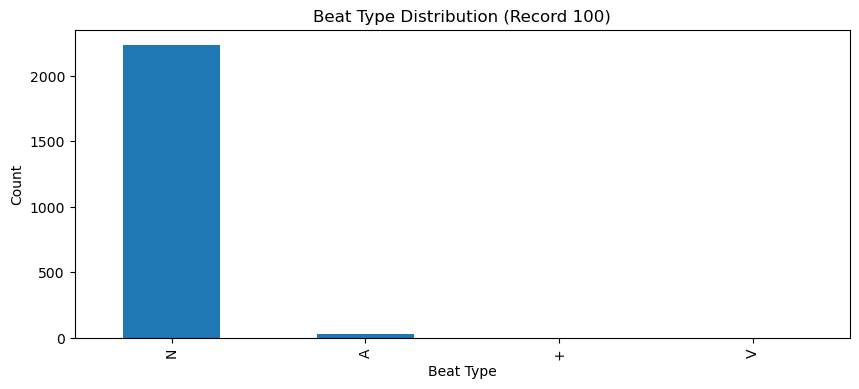

In [76]:
df.symbol.value_counts().plot(kind='bar', figsize=(10,4))
plt.title("Beat Type Distribution (Record 100)")
plt.xlabel("Beat Type")
plt.ylabel("Count")
plt.show()


In [77]:
from collections import Counter
all_beats = Counter()

for r in records:
    ann = wfdb.rdann(os.path.join(DATA_PATH, r), "atr")
    all_beats.update(ann.symbol)

pd.Series(all_beats).sort_values(ascending=False)


N    75052
L     8075
R     7259
V     7130
/     7028
A     2546
+     1291
f      982
F      803
~      616
!      472
"      437
j      229
x      193
a      150
|      132
E      106
J       83
Q       33
e       16
[        6
]        6
S        2
dtype: int64

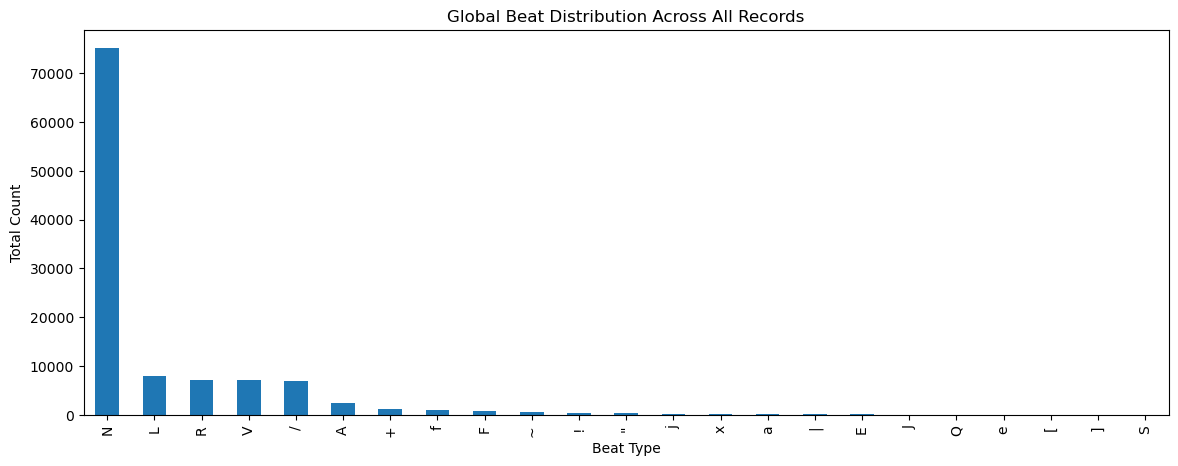

In [79]:
pd.Series(all_beats).sort_values(ascending=False).plot(kind='bar', figsize=(14,5))
plt.title("Global Beat Distribution Across All Records")
plt.xlabel("Beat Type")
plt.ylabel("Total Count")
plt.show()


### Interpretation of MIT-BIH Annotation Symbols

| Symbol | Meaning |
|--------|---------|
| N | Normal beat |
| L | Left bundle branch block |
| R | Right bundle branch block |
| V | Premature ventricular contraction |
| A | Atrial premature beat |
| a | Aberrated atrial premature beat |
| J | Junctional premature beat |
| S | Supra-ventricular premature beat |
| F | Fusion of ventricular and normal beat |
| e | Atrial escape beat |
| j | Junctional escape beat |


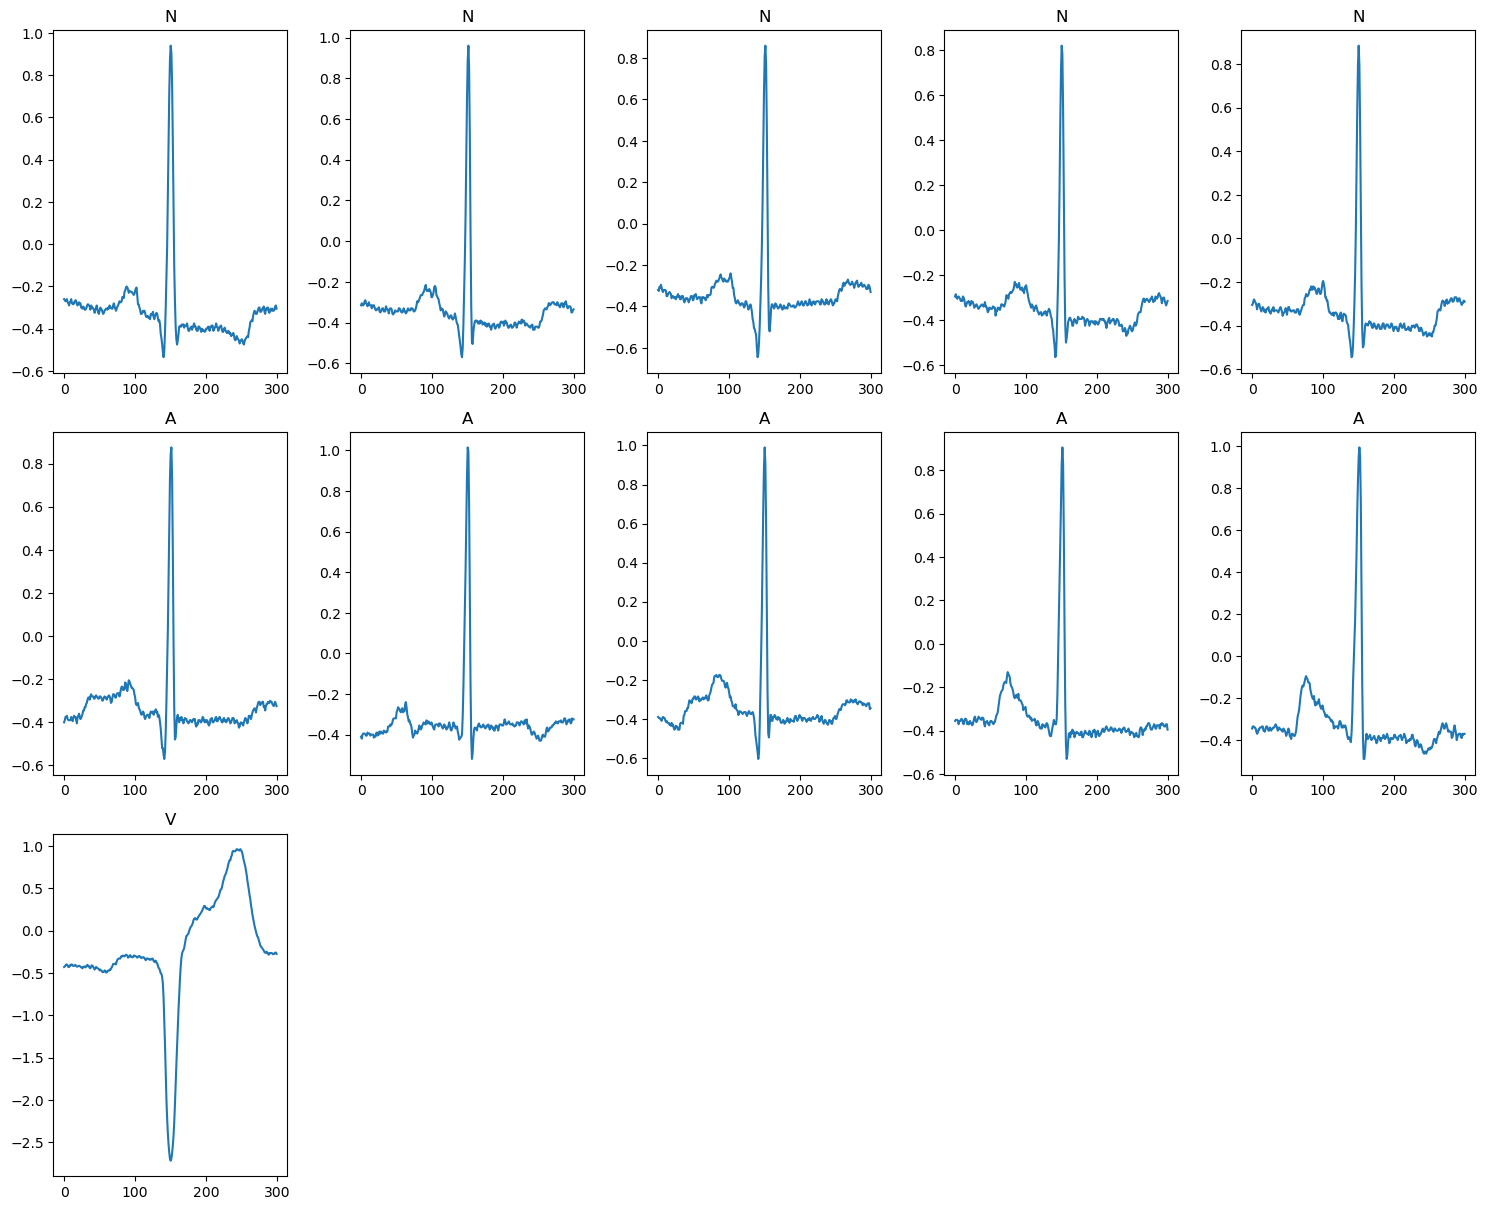

In [82]:
signal = record.p_signal[:,0]
r_peaks = annotation.sample
symbols = annotation.symbol

window = 150
beats_by_class = {}

for i, r in enumerate(r_peaks):
    start, end = r - window, r + window
    if start < 0 or end >= len(signal): continue
    segment = signal[start:end]
    label = symbols[i]
    beats_by_class.setdefault(label, []).append(segment)

# Plot first 5 classes only
plt.figure(figsize=(15,20))
i = 1
for cls, beats in list(beats_by_class.items())[:5]:
    for b in beats[:5]:
        plt.subplot(5,5,i)
        plt.plot(b)
        plt.title(cls)
        i+=1
plt.tight_layout()
plt.show()


In [83]:
record_stats = {}
for r in records:
    ann = wfdb.rdann(os.path.join(DATA_PATH, r), "atr")
    record_stats[r] = len(ann.symbol)

pd.Series(record_stats).describe()


count      48.000000
mean     2346.812500
std       451.689107
min      1519.000000
25%      2061.500000
50%      2299.000000
75%      2650.250000
max      3400.000000
dtype: float64

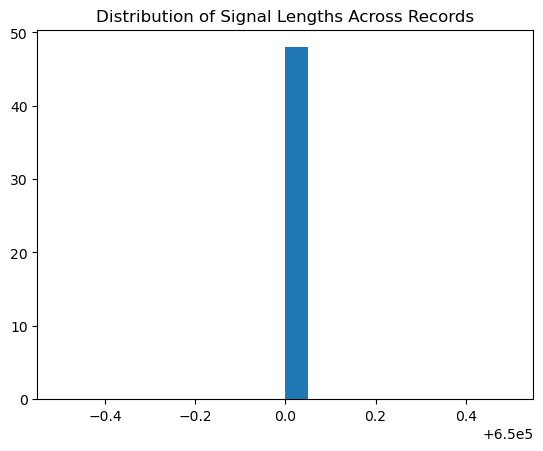

In [86]:
lengths = []
for r in records:
    rec = wfdb.rdrecord(os.path.join(DATA_PATH, r))
    lengths.append(len(rec.p_signal))

plt.hist(lengths, bins=20)
plt.title("Distribution of Signal Lengths Across Records")
plt.show()


# Noise Analysis

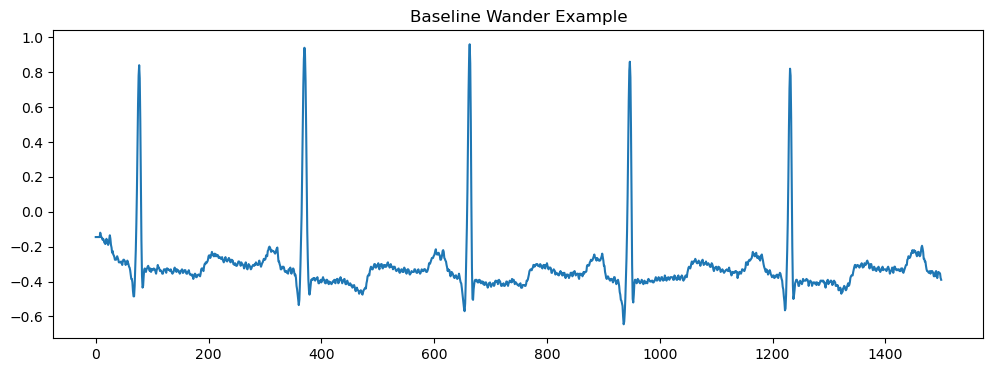

In [89]:
plt.figure(figsize=(12,4))
plt.plot(record.p_signal[0:1500,0])
plt.title("Baseline Wander Example")
plt.show()


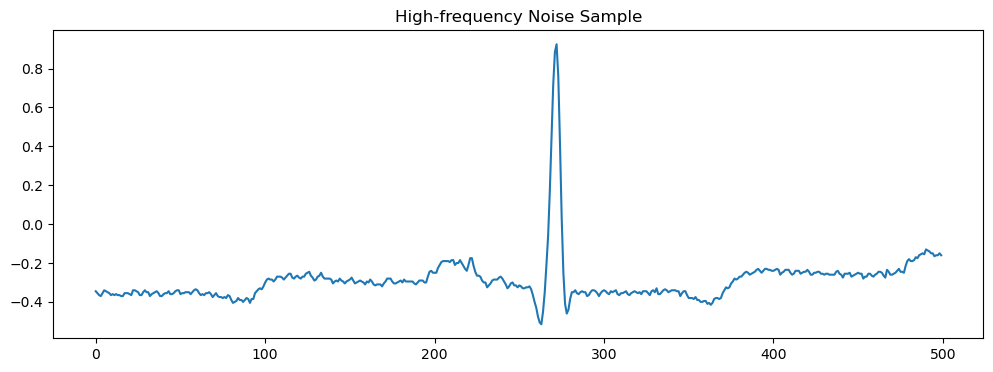

In [90]:
plt.figure(figsize=(12,4))
plt.plot(record.p_signal[20000:20500,0])
plt.title("High-frequency Noise Sample")
plt.show()


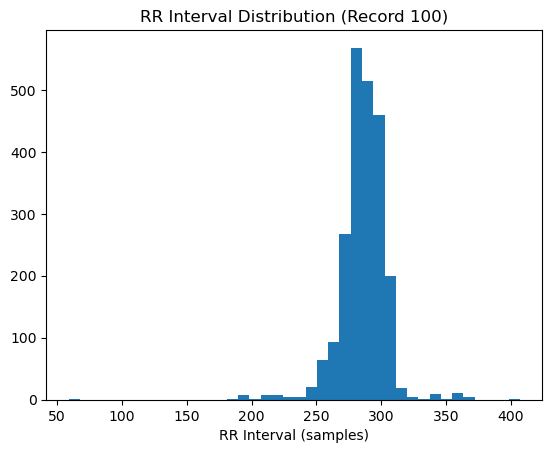

In [91]:
rr_intervals = np.diff(annotation.sample)
plt.hist(rr_intervals, bins=40)
plt.title("RR Interval Distribution (Record 100)")
plt.xlabel("RR Interval (samples)")
plt.show()


### Key EDA Insights

- MIT-BIH signals have rich variety across patients: noise, baseline wander, morphological variations.
- Beat distribution is highly imbalanced (normal beats dominate heavily).
- R-peak distances (RR intervals) reveal heart-rate variability.
- Some records contain severe noise requiring filtering.
- Annotation set includes > 15 beat types requiring grouping.
- Single-beat morphology varies significantly across patients → there will be chances of overfitting in CNN
